# 🛰️ GLOFEagles — Validation Inference Notebook

Unzips the validation dataset from Google Drive and runs inference using pre-trained lake/glacier segmentation weights.

**Model:** U-Net++ · EfficientNet-B3 encoder · TTA (6 augmentations × 3 scales)

In [4]:
!pip install -q -U segmentation-models-pytorch albumentations

## 2 · Imports & Device

In [5]:
import os, glob, zipfile, warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}  |  PyTorch {torch.__version__}")

Using device: cuda  |  PyTorch 2.11.0+cu128


## 3 · Mount Google Drive

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'SESYD_baseline', 'yolo_output', 'ECA_pretrained', 'rash_model', 'CVC-FP', 'Comparison_results', 'Weight for CBAM', 'YOLOv12_baseline', 'YOLO26_baseline', 'yolov12', 'yolo26', 'Latest Model Comparisons.gsheet', 'YOLOv8n with Efficient Channel Attention for Automated Floor Plan Object Detection.gdoc', 'Mule_Account_Detection_Solution (2).gdoc', 'GLOFeagles_Challenge', 'GLOFeagles_Challenge (1)']


## 4 · Configure Paths

> Edit the paths below to match your Drive layout.

In [7]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/GLOFeagles_Challenge"

# Zip file name (exactly as it appears in Drive)
ZIP_NAME     = "GLOFEagles Challenge Validation Dataset-20260618T152553Z-3-001.zip"
ZIP_PATH     = os.path.join(DRIVE_ROOT, ZIP_NAME)
# Model weight files (all three are available — pick which to run)
WEIGHTS = {
    "lake_model": os.path.join(DRIVE_ROOT, "glacier_lake_model_final.pth"),
    "glacier_model": os.path.join(DRIVE_ROOT, "glacier_lake_checkpoint.pth"),
}
# Where to extract images and save output masks
EXTRACT_DIR  = "/content/glof_validation"
OUTPUT_DIR   = os.path.join(DRIVE_ROOT, "GLOF_Validation_Masks2")

# Inference settings
IMG_SIZE     = 512
THRESHOLD    = 0.32          # best from threshold sweep in training notebook
TTA_SCALES   = [384, 512, 640]
MIN_AREA     = 50            # minimum connected-component area (px) to keep
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)

print("Zip exists:",  os.path.exists(ZIP_PATH))
for name, path in WEIGHTS.items():
    print(f"  {name:20s}: exists={os.path.exists(path)}  →  {path}")

Zip exists: True
  lake_model          : exists=True  →  /content/drive/MyDrive/GLOFeagles_Challenge/glacier_lake_model_final.pth
  glacier_model       : exists=True  →  /content/drive/MyDrive/GLOFeagles_Challenge/glacier_lake_checkpoint.pth


## 5 · Extract Validation Zip

In [8]:
import os
import zipfile

print(f"📦 Extracting: {ZIP_PATH}")

# Create extraction directory
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("✅ Extraction complete!\n")

# 🔍 Show proper directory structure (recursive, limited depth)
print("📂 Directory structure (up to 3 levels):\n")

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    if level > 3:
        continue

    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    sub_indent = "  " * (level + 1)
    for f in files[:5]:  # show only first 5 files per folder
        print(f"{sub_indent}📄 {f}")

    if len(files) > 5:
        print(f"{sub_indent}... ({len(files)} files total)")

📦 Extracting: /content/drive/MyDrive/GLOFeagles_Challenge/GLOFEagles Challenge Validation Dataset-20260618T152553Z-3-001.zip
✅ Extraction complete!

📂 Directory structure (up to 3 levels):

📁 glof_validation/
  📁 GLOFEagles Challenge Validation Dataset/
    📁 images/
      📁 Cloud Cover/
        📄 96.png
        📄 10.png
        📄 588.png
        📄 427.png
        📄 192.png
        ... (12 files total)
      📁 Terrain Shadow/
        📄 1681.png
        📄 2022.png
        📄 1068.png
        📄 979.png
        📄 1007.png
        ... (239 files total)
      📁 Moraine Dammed/
        📄 1573.png
        📄 2042.png
        📄 1863.png
        📄 626.png
        📄 978.png
        ... (835 files total)
      📁 Snow Cover/
        📄 334.png
        📄 1818.png
        📄 1207.png
        📄 1721.png
        📄 1174.png
        ... (834 files total)
      📁 Debris Cover/
        📄 1140.png
        📄 2183.png
        📄 951.png
        📄 1742.png
        📄 2191.png
        ... (234 files total)
      📁 V

## 6 · Locate All Validation Images

In [9]:
import os
import glob

IMG_ROOT = os.path.join(
    EXTRACT_DIR,
    "GLOFEagles Challenge Validation Dataset",
    "images"
)

ALL_IMAGE_PATHS = sorted(
    glob.glob(os.path.join(IMG_ROOT, "**", "*.png"), recursive=True)
)

print(f"✅ Total images found: {len(ALL_IMAGE_PATHS)}")

print("First 5 paths:")
for p in ALL_IMAGE_PATHS[:5]:
    print(p)

✅ Total images found: 2220
First 5 paths:
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover/10.png
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover/168.png
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover/192.png
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover/320.png
/content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Cloud Cover/427.png


## 7 · Load Model + Weights

Set  to one of , , or .

In [10]:
# ─── Choose which weights to load ─────────────────────────────────────────────
MODEL_KEY = "lake_model"     # ← change me
# ──────────────────────────────────────────────────────────────────────────────

model = smp.UnetPlusPlus(
    encoder_name    = "efficientnet-b3",
    encoder_weights = None,          # no imagenet re-download; we load custom weights
    in_channels     = 3,
    classes         = 1,
    activation      = None,
)

weight_path = WEIGHTS[MODEL_KEY]
checkpoint  = torch.load(weight_path, map_location=DEVICE)

# Support both raw state-dicts and checkpoint dicts saved with extra metadata
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    if "best_threshold" in checkpoint:
        THRESHOLD = checkpoint["best_threshold"]
        print(f"Using saved threshold from checkpoint: {THRESHOLD}")
else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())

print(f"Loaded '{MODEL_KEY}' - {total_params:,} parameters")
print(f"Inference threshold: {THRESHOLD}")

Loaded 'lake_model' - 13,624,793 parameters
Inference threshold: 0.32


## 8 · Inference with Test-Time Augmentation (TTA)

Replicates the exact TTA pipeline from the training notebook: **6 geometric flips/rotations × 3 scales**, averaged for robust predictions.

In [11]:
def predict_mask_tta(image_path, threshold=THRESHOLD, min_area=MIN_AREA,
                     scales=TTA_SCALES):
    """
    Returns (img_rgb, prob_map, binary_mask).
    Mirrors predict_lake_mask_tta() from the training notebook.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]

    tta_augmented = [
        img_rgb,
        np.fliplr(img_rgb),
        np.flipud(img_rgb),
        np.rot90(img_rgb, 1),
        np.rot90(img_rgb, 2),
        np.rot90(img_rgb, 3),
    ]

    probs_accum = np.zeros((orig_h, orig_w), dtype=np.float32)

    with torch.no_grad():
        for scale in scales:
            preprocess = A.Compose([
                A.Resize(scale, scale),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std =(0.229, 0.224, 0.225)),
                ToTensorV2(),
            ])
            scale_probs = np.zeros((orig_h, orig_w), dtype=np.float32)

            for i, aug_img in enumerate(tta_augmented):
                x    = preprocess(image=aug_img.copy())["image"]                            .unsqueeze(0).float().to(DEVICE)
                prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()

                # Undo TTA transforms
                if   i == 1: prob = np.fliplr(prob)
                elif i == 2: prob = np.flipud(prob)
                elif i == 3: prob = np.rot90(prob, -1)
                elif i == 4: prob = np.rot90(prob, -2)
                elif i == 5: prob = np.rot90(prob, -3)

                prob = cv2.resize(prob, (orig_w, orig_h),
                                  interpolation=cv2.INTER_LINEAR)
                scale_probs += prob

            probs_accum += scale_probs / len(tta_augmented)

    prob_map = probs_accum / len(scales)

    # Threshold → morphological cleanup → small-component removal
    binary = (prob_map > threshold).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    n_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )
    filtered = np.zeros_like(binary)
    for lbl in range(1, n_lbl):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == lbl] = 1

    return img_rgb, prob_map, filtered

print("✅ predict_mask_tta() defined and ready.")

✅ predict_mask_tta() defined and ready.


## 9 · Sanity Check — Preview First 3 Images

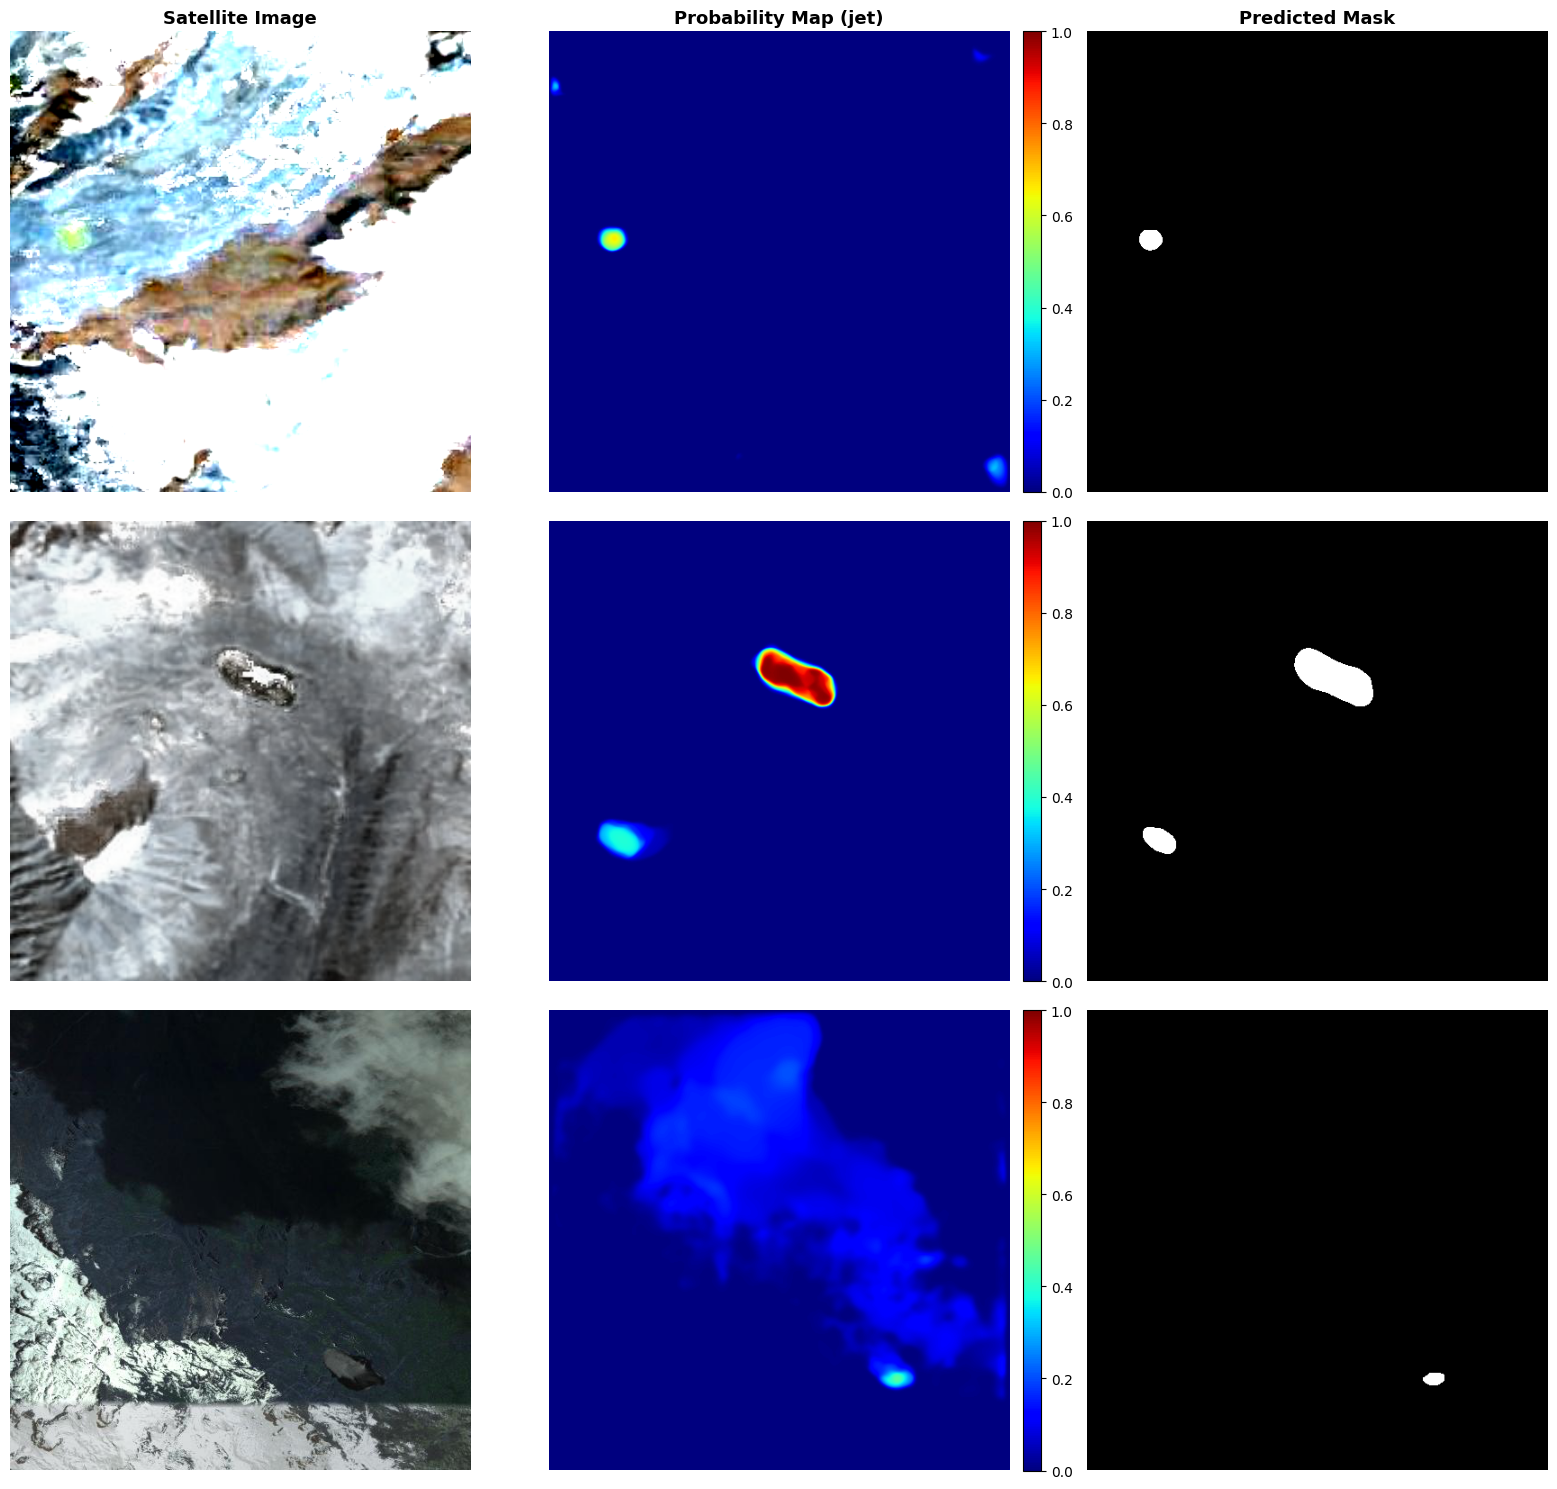

Preview saved at: /content/drive/MyDrive/GLOFeagles_Challenge/GLOF_Validation_Masks2/sanity_check_preview.png


In [12]:
import matplotlib.pyplot as plt
import os

preview_paths = ALL_IMAGE_PATHS[:3]
n = len(preview_paths)

fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n))

# Handle single image case
if n == 1:
    axes = [axes]

# Column titles
col_titles = ["Satellite Image", "Probability Map (jet)", "Predicted Mask"]
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=13, fontweight="bold")

# Loop through images
for row, img_path in enumerate(preview_paths):
    img_rgb, prob_map, pred_mask = predict_mask_tta(img_path)

    lake_pct = 100 * pred_mask.mean()

    # Image
    axes[row][0].imshow(img_rgb)
    axes[row][0].set_ylabel(
        f"{os.path.basename(img_path)}\nLake: {lake_pct:.1f}%",
        fontsize=9
    )

    # Probability map
    im = axes[row][1].imshow(prob_map, cmap="jet", vmin=0, vmax=1)
    cbar_ax = axes[row][1].inset_axes([1.03, 0, 0.04, 1])
    plt.colorbar(im, cax=cbar_ax)

    # Mask
    axes[row][2].imshow(pred_mask, cmap="gray")

    # Remove axes
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()

# Save preview
save_path = os.path.join(OUTPUT_DIR, "sanity_check_preview.png")
plt.savefig(save_path, dpi=150)

plt.show()

print(f"Preview saved at: {save_path}")

## 10 · Run Inference on All Validation Images & Save Masks

In [ ]:
from tqdm.notebook import tqdm
import os
import cv2
import numpy as np

failed, blank, processed = [], 0, 0

for img_path in tqdm(ALL_IMAGE_PATHS, desc="Inferencing"):
    try:
        _, _, pred_mask = predict_mask_tta(img_path)

        mask_out = (pred_mask > 0).astype(np.uint8) * 255

        # Mirror folder structure
        rel_path = os.path.relpath(img_path, EXTRACT_DIR)
        save_path = os.path.join(
            OUTPUT_DIR,
            rel_path.rsplit(".", 1)[0] + "_mask.png"
        )

        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, mask_out)

        if mask_out.sum() == 0:
            blank += 1

        processed += 1

    except Exception as exc:
        failed.append((img_path, str(exc)))

# ✅ FIXED PRINTS
print("\n" + "="*55)
print(f"Images processed  : {processed}")
print(f"Non-empty masks   : {processed - blank}")
print(f"Blank masks       : {blank}  ({100*blank/max(processed,1):.1f}%)")
print(f"Failed            : {len(failed)}")
print(f"Output directory  : {OUTPUT_DIR}")
print("="*55)

if failed:
    print("\nFailed images:")
    for p, e in failed[:10]:
        print(f"{p}  ->  {e}")

Inferencing:   0%|          | 0/2220 [00:00<?, ?it/s]


Images processed  : 2220
Non-empty masks   : 1939
Blank masks       : 281  (12.7%)
Failed            : 0
Output directory  : /content/drive/MyDrive/GLOFeagles_Challenge/GLOF_Validation_Masks


## 11 · Results Gallery (random sample)

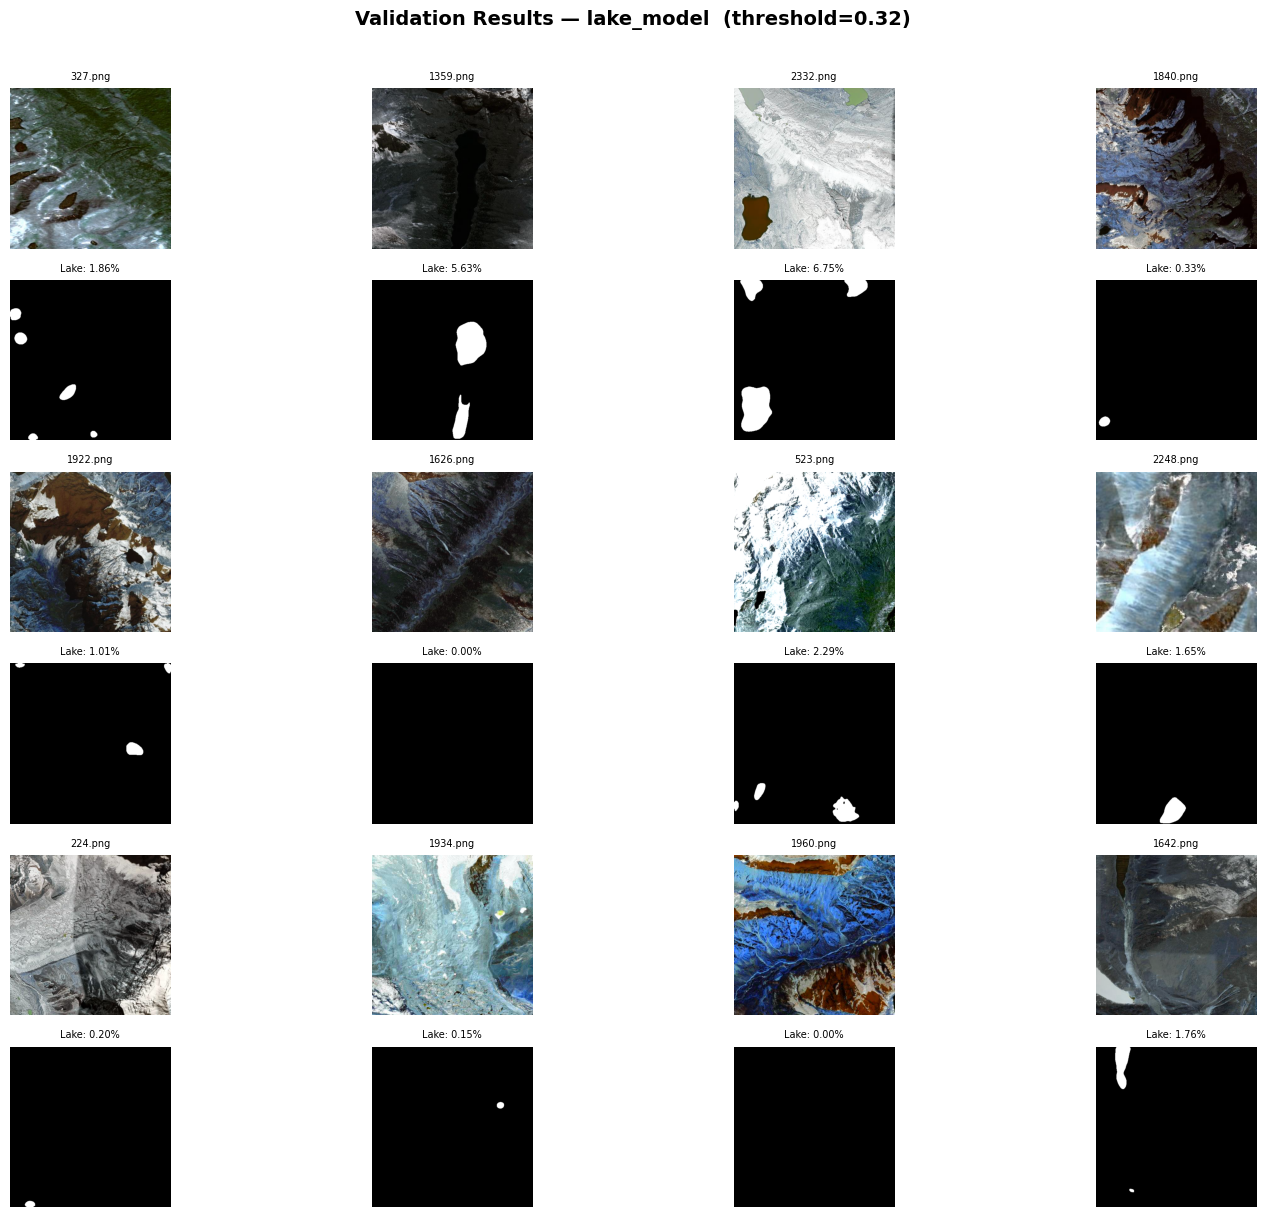

Gallery saved → /content/drive/MyDrive/GLOFeagles_Challenge/GLOF_Validation_Masks/results_gallery.png


In [ ]:
import random

SAMPLE_N = 12   # number of images to visualise

sample_paths = random.sample(ALL_IMAGE_PATHS, min(SAMPLE_N, len(ALL_IMAGE_PATHS)))
cols = 4
rows = (len(sample_paths) + cols - 1) // cols

fig, axes = plt.subplots(rows * 2, cols, figsize=(4 * cols, 4 * rows))

for i, img_path in enumerate(sample_paths):
    row_top = (i // cols) * 2
    col     = i % cols

    img_rgb, prob_map, pred_mask = predict_mask_tta(img_path)

    axes[row_top  ][col].imshow(img_rgb)
    axes[row_top  ][col].set_title(os.path.basename(img_path)[:22], fontsize=7)
    axes[row_top  ][col].axis("off")

    axes[row_top+1][col].imshow(pred_mask, cmap="gray")
    lake_pct = 100 * pred_mask.mean()
    axes[row_top+1][col].set_title(f"Lake: {lake_pct:.2f}%", fontsize=7)
    axes[row_top+1][col].axis("off")

# Hide unused subplots
for j in range(len(sample_paths), rows * cols):
    axes[(j // cols) * 2    ][j % cols].axis("off")
    axes[(j // cols) * 2 + 1][j % cols].axis("off")

plt.suptitle(
    f"Validation Results — {MODEL_KEY}  (threshold={THRESHOLD})",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
gallery_path = os.path.join(OUTPUT_DIR, "results_gallery.png")
plt.savefig(gallery_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gallery saved → {gallery_path}")

## 12 · Output Quality Check

In [ ]:
saved_masks = sorted(glob.glob(os.path.join(OUTPUT_DIR, "**", "*_mask.png"), recursive=True))

lake_pcts = []
for mp in saved_masks:
    img = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        lake_pcts.append(100 * (img > 0).mean())

print(f"Total saved masks      : {len(saved_masks)}")
if lake_pcts:
    print(f"With lake pixels       : {sum(p > 0 for p in lake_pcts)}")
    print(f"Completely blank       : {sum(p == 0 for p in lake_pcts)}")
    print(f"Mean lake coverage     : {np.mean(lake_pcts):.2f}%")
    print(f"Median lake coverage   : {np.median(lake_pcts):.2f}%")
    print(f"Max lake coverage      : {np.max(lake_pcts):.2f}%")

    plt.figure(figsize=(10, 4))
    plt.hist(lake_pcts, bins=40, color="steelblue", edgecolor="white")
    plt.xlabel("Lake pixel coverage (%)")
    plt.ylabel("Number of images")
    plt.title(f"Distribution of predicted lake coverage — {MODEL_KEY}")
    plt.tight_layout()
    hist_path = os.path.join(OUTPUT_DIR, "coverage_histogram.png")
    plt.savefig(hist_path, dpi=150)
    plt.show()
    print(f"Histogram saved → {hist_path}")

Total saved masks      : 0


## 13 · (Optional) Compare All Three Models on One Image

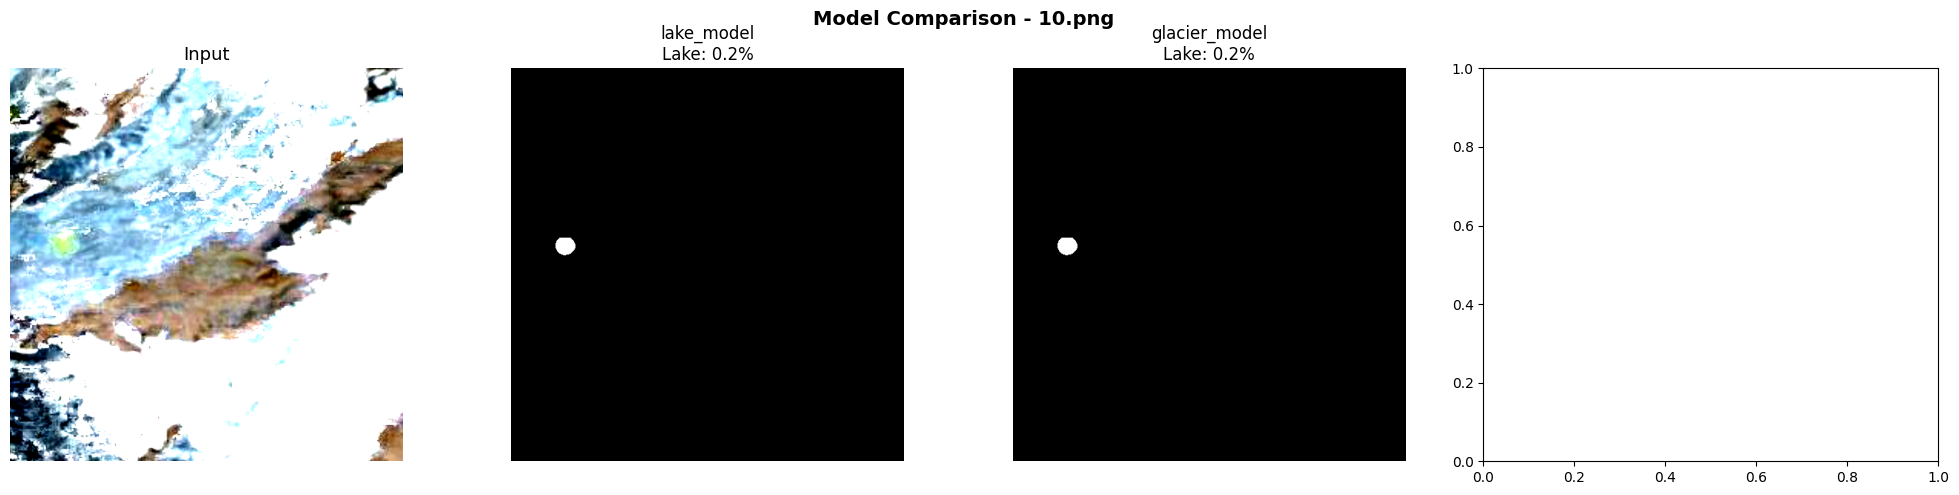

Comparison figure saved -> /content/drive/MyDrive/GLOFeagles_Challenge/GLOF_Validation_Masks/model_comparison.png
Restored: lake_model


In [ ]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

TEST_IMAGE = ALL_IMAGE_PATHS[0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

img_rgb = cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb)
axes[0].set_title("Input", fontsize=13)
axes[0].axis("off")

for ax, (name, wpath) in zip(axes[1:], WEIGHTS.items()):

    if not os.path.exists(wpath):
        ax.text(
            0.5, 0.5,
            f"{name}\nnot found",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    # Load weights
    ckpt = torch.load(wpath, map_location=DEVICE)
    sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

    model.load_state_dict(sd, strict=True)
    model.eval()

    _, prob_map, pred_mask = predict_mask_tta(TEST_IMAGE)

    ax.imshow(pred_mask, cmap="gray")
    ax.set_title(
        f"{name}\nLake: {100*pred_mask.mean():.1f}%",
        fontsize=12
    )
    ax.axis("off")

plt.suptitle(
    f"Model Comparison - {os.path.basename(TEST_IMAGE)}",
    fontsize=14, fontweight="bold"
)

plt.tight_layout()

cmp_path = os.path.join(OUTPUT_DIR, "model_comparison.png")
plt.savefig(cmp_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Comparison figure saved -> {cmp_path}")

# Restore original model
ckpt = torch.load(WEIGHTS[MODEL_KEY], map_location=DEVICE)
sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

model.load_state_dict(sd, strict=True)
model.eval()

print(f"Restored: {MODEL_KEY}")

In [ ]:
import os
import glob

GT_ROOT = os.path.join(
    EXTRACT_DIR,
    "GLOFEagles Challenge Validation Dataset",
    "labels"
)

PRED_ROOT = OUTPUT_DIR

pairs = []

for root, _, files in os.walk(GT_ROOT):
    for f in files:
        if not f.endswith(".png"):
            continue

        gt_path = os.path.join(root, f)

        rel = os.path.relpath(gt_path, GT_ROOT)
        pred_path = os.path.join(
            PRED_ROOT,
            "GLOFEagles Challenge Validation Dataset",
            "images",
            rel.replace(".png", "_mask.png")
        )

        if os.path.exists(pred_path):
            pairs.append((gt_path, pred_path))

print("Total matched pairs:", len(pairs))

Total matched pairs: 0


In [ ]:
import numpy as np
import cv2

def compute_iou(gt, pred):
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return intersection / union

In [ ]:
ious = []

for gt_path, pred_path in pairs:
    gt = cv2.imread(gt_path, 0)
    pred = cv2.imread(pred_path, 0)

    if gt.shape != pred.shape:
        pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]))

    iou = compute_iou(gt, pred)
    ious.append(iou)

print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Min IoU : {np.min(ious):.4f}")
print(f"Max IoU : {np.max(ious):.4f}")

Mean IoU: 0.4211
Min IoU : 0.0000
Max IoU : 0.9677


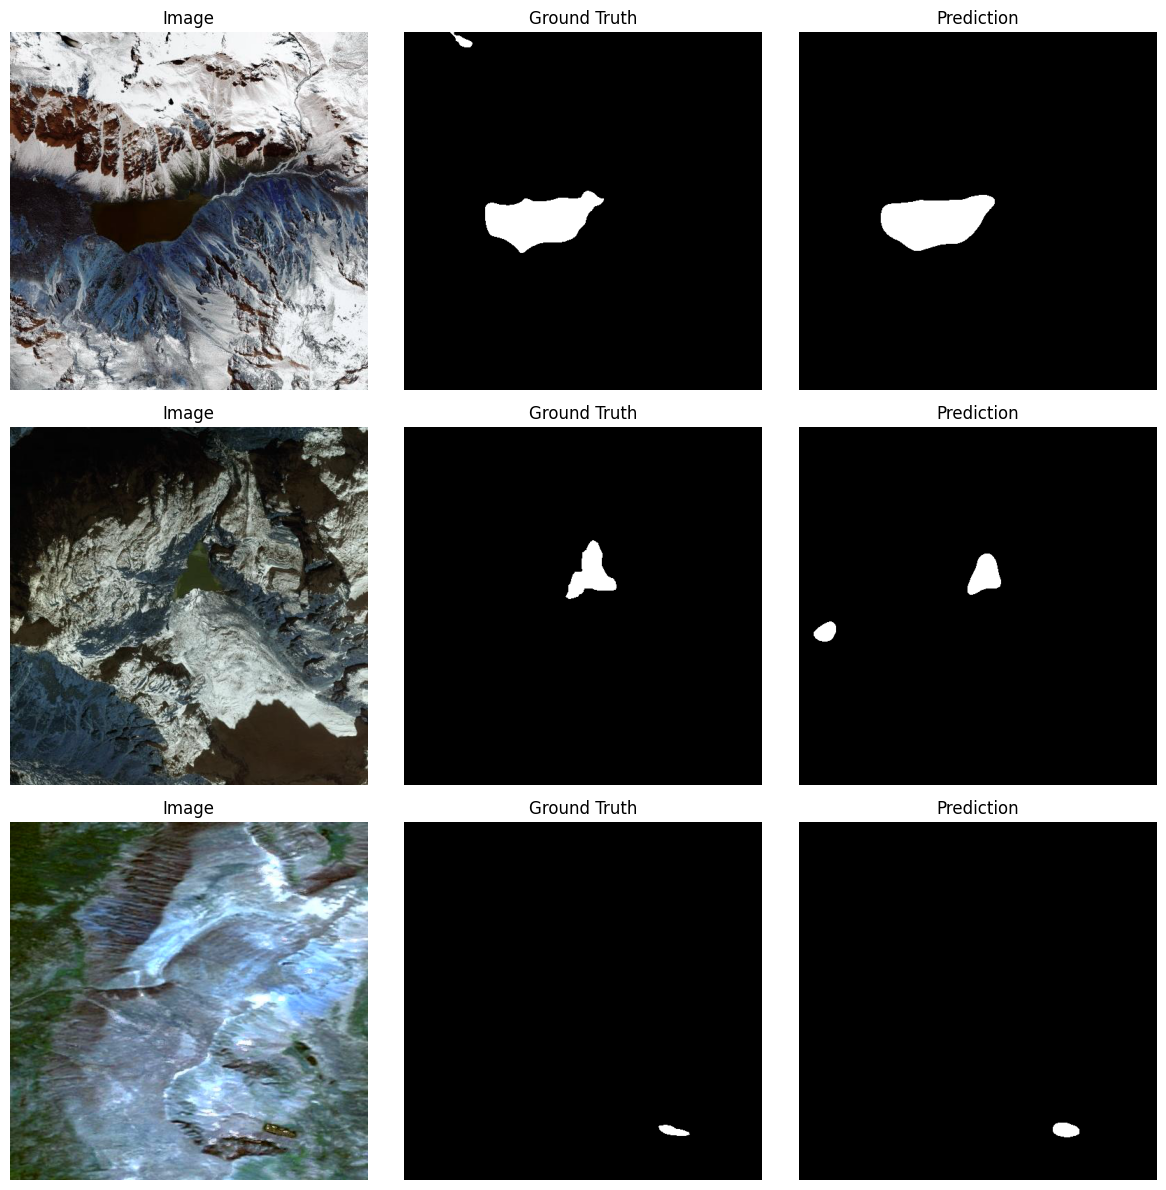

In [ ]:
import matplotlib.pyplot as plt
import random

samples = random.sample(pairs, 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, (gt_path, pred_path) in enumerate(samples):
    img_path = gt_path.replace("labels", "images")

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(gt_path, 0)
    pred = cv2.imread(pred_path, 0)

    axes[i][0].imshow(img)
    axes[i][0].set_title("Image")

    axes[i][1].imshow(gt, cmap="gray")
    axes[i][1].set_title("Ground Truth")

    axes[i][2].imshow(pred, cmap="gray")
    axes[i][2].set_title("Prediction")

    for j in range(3):
        axes[i][j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_samples.png"))
plt.show()

In [9]:
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from tqdm.notebook import tqdm

SAVE_DIR = os.path.join(OUTPUT_DIR, "final_comparisons")
os.makedirs(SAVE_DIR, exist_ok=True)

GT_ROOT = os.path.join(
    EXTRACT_DIR,
    "GLOFEagles Challenge Validation Dataset",
    "labels"
)

def compute_metrics(gt, pred):
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    iou = intersection / union if union > 0 else 1.0
    dice = (2 * intersection) / (gt.sum() + pred.sum() + 1e-6)
    acc = (gt == pred).mean()

    return acc, iou, dice

for img_path in tqdm(ALL_IMAGE_PATHS, desc="Generating outputs"):
    try:
        # Paths
        rel = os.path.relpath(
            img_path,
            os.path.join(EXTRACT_DIR, "GLOFEagles Challenge Validation Dataset", "images")
        )
        gt_path = os.path.join(GT_ROOT, rel)

        if not os.path.exists(gt_path):
            continue

        # Load
        img_rgb, prob_map, pred_mask = predict_mask_tta(img_path)
        gt = cv2.imread(gt_path, 0)

        if gt.shape != pred_mask.shape:
            pred_mask = cv2.resize(pred_mask, (gt.shape[1], gt.shape[0]))

        # Metrics
        acc, iou, dice = compute_metrics(gt, pred_mask)

        # Plot (NOW 4 PANELS)
        fig, axes = plt.subplots(1, 4, figsize=(18, 5))

        axes[0].imshow(img_rgb)
        axes[0].set_title("Original")

        axes[1].imshow(gt, cmap="gray")
        axes[1].set_title("Ground Truth")

        axes[2].imshow(pred_mask, cmap="gray")
        axes[2].set_title("Prediction")

        # Metrics panel
        axes[3].axis("off")
        axes[3].text(
            0.1, 0.5,
            f"Accuracy : {acc:.4f}\n"
            f"IoU      : {iou:.4f}\n"
            f"Dice     : {dice:.4f}",
            fontsize=12,
            verticalalignment='center'
        )

        for ax in axes[:3]:
            ax.axis("off")

        plt.tight_layout()

        # Save
        filename = os.path.basename(img_path).replace(".png", "_final.png")
        save_path = os.path.join(SAVE_DIR, filename)

        plt.savefig(save_path, dpi=100)
        plt.close()

    except Exception as e:
        print("Error:", img_path, e)

print(f"\nDone! Saved in: {SAVE_DIR}")

Generating outputs:   0%|          | 0/2220 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from tqdm import tqdm

# 🔥 RESUME POINT
START_IDX = 1672
ALL_IMAGE_PATHS = ALL_IMAGE_PATHS[START_IDX:]

SAVE_DIR = os.path.join(OUTPUT_DIR, "final_comparisons")
os.makedirs(SAVE_DIR, exist_ok=True)

GT_ROOT = os.path.join(
    EXTRACT_DIR,
    "GLOFEagles Challenge Validation Dataset",
    "labels"
)

def compute_metrics(gt, pred):
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)

    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()

    iou = intersection / union if union > 0 else 1.0
    dice = (2 * intersection) / (gt.sum() + pred.sum() + 1e-6)
    acc = (gt == pred).mean()

    return acc, iou, dice


for idx, img_path in enumerate(tqdm(ALL_IMAGE_PATHS, desc="Resuming from 1672")):
    try:
        print(f"Processing index {START_IDX + idx}: {img_path}")

        # Paths
        rel = os.path.relpath(
            img_path,
            os.path.join(EXTRACT_DIR, "GLOFEagles Challenge Validation Dataset", "images")
        )
        gt_path = os.path.join(GT_ROOT, rel)

        if not os.path.exists(gt_path):
            continue

        # Load
        img_rgb, prob_map, pred_mask = predict_mask_tta(img_path)
        gt = cv2.imread(gt_path, 0)

        if gt is None:
            print("Skipping bad GT:", gt_path)
            continue

        if gt.shape != pred_mask.shape:
            pred_mask = cv2.resize(pred_mask, (gt.shape[1], gt.shape[0]))

        # Metrics
        acc, iou, dice = compute_metrics(gt, pred_mask)

        # Plot
        fig, axes = plt.subplots(1, 4, figsize=(12, 4))

        axes[0].imshow(img_rgb)
        axes[0].set_title("Original")

        axes[1].imshow(gt, cmap="gray")
        axes[1].set_title("GT")

        axes[2].imshow(pred_mask, cmap="gray")
        axes[2].set_title("Pred")

        axes[3].axis("off")
        axes[3].text(
            0.1, 0.5,
            f"Acc: {acc:.3f}\nIoU: {iou:.3f}\nDice: {dice:.3f}",
            fontsize=10
        )

        for ax in axes[:3]:
            ax.axis("off")

        plt.tight_layout()

        # Save
        filename = os.path.basename(img_path).replace(".png", "_final.png")
        save_path = os.path.join(SAVE_DIR, filename)

        plt.savefig(save_path, dpi=80)

        # ✅ MEMORY CLEANUP
        plt.close(fig)
        del fig, axes

    except Exception as e:
        print("Error:", img_path, e)
        continue

print("\nDone. Resumed from 1672 and completed remaining images.")

Resuming from 1672:   0%|          | 0/548 [00:00<?, ?it/s]

Processing index 1672: /content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Snow Cover/364.png


Resuming from 1672:   0%|          | 1/548 [00:01<10:30,  1.15s/it]

Processing index 1673: /content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Snow Cover/37.png


Resuming from 1672:   0%|          | 2/548 [00:02<09:59,  1.10s/it]

...

Processing index 2218: /content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Varying Turbidity/2333.png


Resuming from 1672: 100%|█████████▉| 547/548 [10:34<00:01,  1.12s/it]

Processing index 2219: /content/glof_validation/GLOFEagles Challenge Validation Dataset/images/Varying Turbidity/2365.png


Resuming from 1672: 100%|██████████| 548/548 [10:35<00:00,  1.16s/it]


Done. Resumed from 1672 and completed remaining images.


In [16]:
import os

SAVE_DIR = os.path.join(OUTPUT_DIR, "final_comparisons")

total = len([
    f for f in os.listdir(SAVE_DIR)
    if f.endswith(".png")
])

print("Total images:", total)

Total images: 2220
